# Duplicate incident matching

**Recipe 18** · Level 2 (Easy) · Decision type: `Choice`

Select a matching incident from a retrieved ticket shortlist, or no match, using descriptions of the symptoms and affected service.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)

## What you will build

An incident-deduplication assistant. Python holds a fixed pool of eight open incidents and, for each new ticket, retrieves a shortlist of the three whose symptom wording overlaps most with the new ticket's (plain word overlap, no model call); Jev then reads one `Choice` question and picks exactly one of four options: one of those three candidate incident identifiers, or the explicit fallback `no_match` the use case names for a ticket that matches none of them. Python owns everything else: the retrieval, the candidate descriptions, and the rule that links a confident real match to its candidate (the one outcome with a simulated side effect), reports `no_match` as a final "this is a new incident" result whatever its confidence, and sends anything else uncertain to an explicit `review` outcome instead of guessing. This notebook replays 31 hand-written synthetic answers (14 `validation`, 15 `test`, 2 `demo`), four of them wrong on purpose and in four different ways, so the lesson about what a confidence gate can and cannot catch is an honest one. By the end you will have looked at individual typed answers across the full range of confidence -- including the central trap this use case names, a ticket that reads almost like an open incident but names a different service -- seen the rule that acts on them, watched its one simulated side effect (linking two incidents together) actually fire on a wrong pair, and run an evaluation that chooses its one setting on `validation` and reports top-1 match accuracy, coverage, risk and the false-merge rate on `test`.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 31 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_outcomes,
    per_class_metrics,
    select_confidence_threshold,
    selective_curve,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ActionLog, ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    plot_risk_coverage,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# The simulated side effects this recipe can produce: a link between two incidents (the only
# outcome with a side effect) and a queue of tickets held for a person to look at. Nothing here
# sends, moves or changes anything real (jev_cookbook.simulation; CONTRIBUTING.md section 4).
actions = ActionLog()
queue = ReviewQueue()

# Every one of the 31 examples in fixtures/ needs at most one request. This cache makes sure a
# ticket that is shown individually and later scored in its split is decided once, so the whole
# notebook makes exactly 31 requests in live mode, never more.
decided = {}


def decide(example):
    if example.id not in decided:
        candidates = helpers.shortlist(example.fields["symptoms"])
        questions = helpers.build_questions(candidates)
        answer = backend.decide(helpers.build_state(example.fields), questions)["match"]
        decided[example.id] = (candidates, answer)
    return decided[example.id]


run_header(
    18,
    "Duplicate incident matching",
    backend=backend,
    n_examples=len(scored),
)

Recipe 18: Duplicate incident matching
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 29 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `ticket_id`, the new ticket's `service` and its `symptoms`, as separate fields (the use case's own build note). `build_state` passes on the symptoms and service only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its ticket.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-near-billing-wrongservice"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "ticket_id": "TCK-3001",
  "service": "wallet-service",
  "symptoms": "Some wallet balance transfers with available funds are being declined intermittently."
}
Jev sees:
{
  "symptoms": "Some wallet balance transfers with available funds are being declined intermittently.",
  "service": "wallet-service"
}


## The questions

There is one question, and it asks one thing: does this new ticket describe the same underlying problem as any of the candidate incidents, or none of them? A `Choice` fits because the outcomes are exclusive and Jev should commit to exactly one ([S02](https://docs.typesafe.ai/primitives) describes `Choice` as picking exactly one option from a fixed, known set with no inherent order). Python retrieves the candidates before Jev ever sees the ticket: `shortlist` in `helpers.py` ranks the eight open incidents by plain word overlap with the new ticket's symptoms -- no model call, no learned embedding -- and keeps the top three. The cell below prints `similarity_scores`, the raw overlap this ticket gets against every open incident, so the ranking is visible rather than only its result. Retrieval ranks on symptom text alone; it never looks at the affected service, on purpose, so a textually similar incident on the *wrong* service can still be retrieved right next to the real one it echoes. Telling those two apart is exactly the judgment this question asks Jev to make, which is why the shared instructions state the matching rule in words: two incidents are the same only when they describe the same underlying problem *and* affect the same service. Each candidate's own description carries its own service and symptoms, so the information needed to apply that rule is there for every option. The fourth option, `no_match`, is the explicit fallback the use case names for a ticket that matches none of the three candidates.

A `Choice` answer's `confidence` ([confidence](../../docs/glossary.md#confidence) in this cookbook's glossary) is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)` ([S03](https://docs.typesafe.ai/confidence)): with four options here, 0 when the top option holds no more than a quarter of the probability, 1 when one option holds all of it. The option list -- and so this formula's `n` -- is part of what `replay_key` hashes, along with the state; because the shortlist is built fresh per ticket, each ticket's request has its own key, and changing `shortlist` invalidates every stored answer at once (`tests/test_helpers.py` catches exactly this: `test_every_replay_key_in_the_fixtures_matches_the_current_question`).

[S04](https://docs.typesafe.ai/concepts/how-to-build-with-system-one) frames this kind of decision as one narrow judgment embedded in code that keeps control flow: Jev picks an option, and Python (`match_incident` in `helpers.py`, below) decides what that option is allowed to do -- link the two incidents together, report `no_match` as a final result, or hold the answer back for review.

In [3]:
scores = helpers.similarity_scores(example.fields["symptoms"])
print("retrieval similarity against every open incident:")
for incident_id, score in sorted(scores.items(), key=lambda kv: (-kv[1], kv[0])):
    print(f"  {incident_id}  {score:.4f}")

candidates, _ = decide(example)
print()
print("shortlist (top 3):", candidates)
questions = helpers.build_questions(candidates)
match = questions["match"]
print()
print(match.instructions)
print()
for name, description in match.criteria.items():
    print(f"{name}")
    print(f"  {description}")

retrieval similarity against every open incident:
  INC-105  0.2500
  INC-102  0.0625
  INC-101  0.0000
  INC-103  0.0000
  INC-104  0.0000
  INC-106  0.0000
  INC-107  0.0000
  INC-108  0.0000

shortlist (top 3): ['INC-105', 'INC-102', 'INC-101']

A new incident report is below. Does it describe the same underlying problem as any of the candidate incidents, or none of them? Two incidents are the same only when they describe the same underlying problem and affect the same service; similar symptoms on a different service are not a match.

INC-105
  Existing incident INC-105, affecting the billing-gateway service. Reported symptoms: Card payments are declined intermittently even though the card is valid and has funds.
INC-102
  Existing incident INC-102, affecting the auth-service service. Reported symptoms: Users are intermittently signed out mid-session with no error message shown.
INC-101
  Existing incident INC-101, affecting the checkout-api service. Reported symptoms: Checkout fail

## One answer up close

Before any aggregate number, look at three typed answers across the range this recipe covers: a near duplicate that reads almost like an open incident but names a different service (this recipe's central trap), a ticket that matches nothing in the open pool at all, and a `validation` ticket whose stored answer falls into the trap and gets it wrong. Each answer holds the chosen option, a probability for every option, the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call. These three come from the `demo` and `validation` splits only; `test` is reported once, after every choice below is frozen, not peeked at here.

wallet-service -- Some wallet balance transfers with available funds are being declined intermittently.
Choice: no_match (confidence 0.60)
  no_match  0.70  ##############
  INC-105   0.10  ##
  INC-102   0.10  ##
  INC-101   0.10  ##
Provenance: synthetic


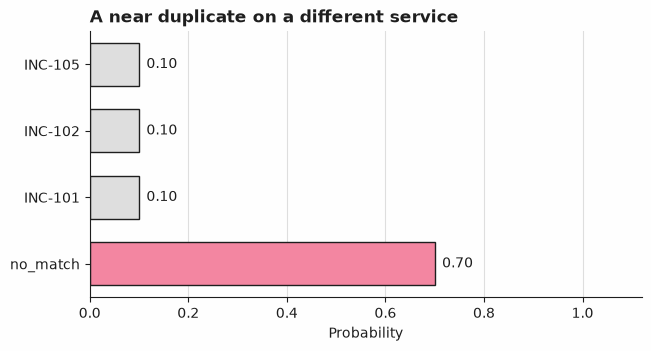

In [4]:
near_dup_example = demo["d01-near-billing-wrongservice"]
near_dup_candidates, near_dup_answer = decide(near_dup_example)
print(near_dup_example.fields["service"], "--", near_dup_example.fields["symptoms"])
show_answer(near_dup_answer)
plot_answer_probabilities(near_dup_answer, title="A near duplicate on a different service")

The ticket is about `wallet-service`, and its wording echoes `INC-105` (billing-gateway: cards declined despite valid funds and available balance) closely enough that `INC-105` is retrieved as a candidate. But a wallet balance transfer is not a card payment, and the affected service is not `billing-gateway`, so the stored answer correctly puts `no_match` well ahead, at a confidence of 0.60: `(0.70 - 0.25) / 0.75`. The next section applies the rule to this answer too, and the one further down gets this exact trap wrong.

In [5]:
clean_example = demo["d02-nomatch-clean"]
clean_candidates, clean_answer = decide(clean_example)
print(clean_example.fields["service"], "--", clean_example.fields["symptoms"])
show_answer(clean_answer)

docs-site -- The documentation site's search bar highlights the wrong section when you click a result.
Choice: no_match (confidence 0.80)
  no_match  0.85  #################
  INC-108   0.05  #
  INC-103   0.05  #
  INC-101   0.05  #
Provenance: synthetic


Two incidents share a single word with this ticket, and nothing more: `INC-108` (search-index) shares "wrong", at a similarity of 0.0625, and `INC-103` (search-index) shares "search", at 0.0556 -- the pool's two strongest matches here, thin as they both are. The other six incidents share nothing with it at all, so the third candidate, `INC-101`, falls to the lowest id among that six-way tie, not because the pool's weakest matches cluster at the bottom of the id order. `no_match` leads clearly regardless, at a confidence of 0.80. Its exact confidence does not matter for what Python does with it: `match_incident`, below, reports `no_match` as a final result whatever its confidence, because the option itself already says no candidate is the same incident -- there is no side effect (no link) a confidence gate could protect here.

In [6]:
wrong_example = next(e for e in examples if e.id == "v08-near-search-wrong")
wrong_candidates, wrong_answer = decide(wrong_example)
print(wrong_example.fields["service"], "--", wrong_example.fields["symptoms"])
show_answer(wrong_answer)

internal-support-tool -- Searches on the partner portal return zero results for terms that matched items yesterday.
Choice: INC-103 (confidence 0.23)
  INC-103   0.42  ########
  INC-108   0.19  ####
  INC-101   0.19  ####
  no_match  0.19  ####
Provenance: synthetic


The **gold label** here -- the correct answer written down in `labels.jsonl` before this notebook ever runs, decided from the matching rule above and not from the model -- is `no_match`: this ticket is about the `internal-support-tool` service, not `search-index`. The stored answer gets the same trap wrong that the first answer above got right: it names `INC-103` (search-index: searches returning zero results) at a confidence of 0.23, a real, named candidate, not `no_match`, and -- as the sweep two sections down shows -- the highest-confidence mistake among the nine `validation` real-candidate answers the gate is chosen from. Two `test` answers shown later are wrong and far more confident still (`t07-near-cart-wrong` at 0.87, `t11-dup-auth-missed` at 0.67), but neither takes part in this selection: the gate is chosen from `validation` alone. This is the one wrong answer this recipe places in `validation` itself, on purpose: without it, every real-candidate answer in `validation` would be correct, and the confidence gate chosen two sections down would have nothing to cut on.

## Python's part

Jev supplies the judgment; what happens with it is code. `match_incident` in `helpers.py` links a confident real candidate to the new ticket, reports `no_match` as a final, un-gated result whatever its confidence (there is no side effect a confidence gate could protect there), sends an option outside the retrieved shortlist to review as a defensive check (`build_questions` never actually offers such an option, but the rule does not trust that silently), and sends a real candidate below the gate to review instead of linking on a guess. `tests/test_helpers.py` checks the rule at the boundary, outside 0 to 1, for a confident and a low-confidence answer of every candidate shape, and for `no_match` at both a high and a low confidence, so a rule that quietly exempted a candidate from the gate, or started gating `no_match` on confidence after all, would fail it.

The **confidence gate** itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest gate whose answered subset is perfectly accurate, over the `validation` answers that name a real candidate (the ones that name `no_match` are excluded from this selection on purpose -- `match_incident` never applies the gate to them, so feeding their confidence into the same selection would tune a gate the rule does not have). `v08-near-search-wrong` above is the one wrong answer in that pool; the frozen gate is the lowest cut that excludes it. Applying that frozen gate to the three answers shown above, plus one clearly confident true duplicate for contrast, shows all three outcomes the rule can produce -- including, for the first time, a ticket sent to `review` -- and the decision Python makes for each, without yet touching the simulated side effect (that happens for real, over every scored ticket, in the Evaluation section below).

In [7]:
val_examples = select_split(examples, "validation")
val_decided = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]

# Only the answers that name a real candidate go into the gate selection: a no_match answer is
# never gated on confidence, so its confidence has no business tuning the gate.
real_match = [
    (a.choice == g, a.confidence)
    for (_c, a), g in zip(val_decided, val_gold, strict=True)
    if a.choice != helpers.NO_MATCH
]
real_correct = [correct for correct, _ in real_match]
real_confidence = [conf for _, conf in real_match]
n_wrong_in_pool = sum(1 for correct in real_correct if not correct)
gate = select_confidence_threshold(real_correct, real_confidence, target_accuracy=1.0)
print(
    f"chosen confidence gate, frozen from here on: {gate:.4f} "
    f"(over {len(real_match)} real-candidate matches in validation, "
    f"{n_wrong_in_pool} of them wrong){selection}"
)

confident_example = next(e for e in val_examples if e.id == "v01-dup-checkout")
confident_candidates, confident_answer = decide(confident_example)
for shown_example, (shown_candidates, shown_answer) in (
    (near_dup_example, (near_dup_candidates, near_dup_answer)),
    (clean_example, (clean_candidates, clean_answer)),
    (wrong_example, (wrong_candidates, wrong_answer)),
    (confident_example, (confident_candidates, confident_answer)),
):
    result = helpers.match_incident(
        shown_example.fields["ticket_id"], shown_candidates, shown_answer, gate
    )
    print(
        f"{result.ticket_id}: {shown_answer.choice} at confidence "
        f"{shown_answer.confidence:.2f} -> {result.outcome} ({result.reason})"
    )

chosen confidence gate, frozen from here on: 0.8400 (over 9 real-candidate matches in validation, 1 of them wrong) (a selection step, not a reported result)
TCK-3001: no_match at confidence 0.60 -> no_duplicate (no open incident matches)
TCK-3002: no_match at confidence 0.80 -> no_duplicate (no open incident matches)
TCK-1008: INC-103 at confidence 0.23 -> review (confidence below the threshold)
TCK-1001: INC-101 at confidence 0.84 -> linked (confident match)


Why that particular cut and not some other number nearby? `selective_curve` sweeps every distinct confidence value this pool actually has and reports the coverage, accuracy and risk of cutting there, so the choice above can be checked rather than taken on faith. **Coverage** is the fraction of this pool a cut answers (confidence at or above it) instead of sending to review; **risk** is `1 - accuracy` among those answered. There are nine real-candidate answers in `validation`, but only four distinct confidences among them -- 0.1067, 0.1733, 0.2267 and 0.84 -- so there are only four cuts to sweep, and `select_confidence_threshold` can only ever return one of those four, never a value in between. Cutting anywhere in the gap `(0.2267, 0.84]` would answer exactly the six confident true duplicates and exclude `v08-near-search-wrong` along with every other low-confidence answer, giving the same coverage (0.6667) and the same risk (0.0000) throughout that gap, but 0.84 is the only one of the four observed confidences that actually falls inside it -- which is why the selector returns 0.84: among the candidates that meet the target accuracy, it picks the lowest one, for the most coverage, and 0.84 is both the lowest and the only option here. Cutting at or below 0.2267 lets `v08-near-search-wrong` itself through, which is exactly the mistake the gate exists to exclude.

cut-off 0.8400: coverage 0.6667, accuracy 1.0000, risk 0.0000 (a selection step, not a reported result) <- chosen
cut-off 0.2267: coverage 0.7778, accuracy 0.8571, risk 0.1429 (a selection step, not a reported result)
cut-off 0.1733: coverage 0.8889, accuracy 0.8750, risk 0.1250 (a selection step, not a reported result)
cut-off 0.1067: coverage 1.0000, accuracy 0.8889, risk 0.1111 (a selection step, not a reported result)


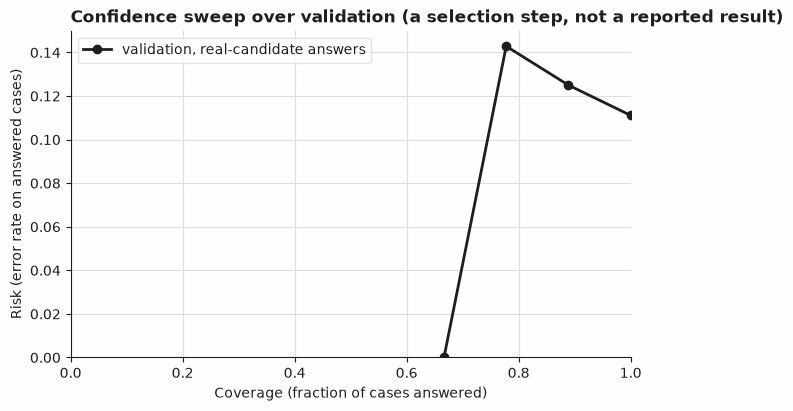

In [8]:
curve = selective_curve(real_correct, real_confidence)
zipped = zip(curve.thresholds, curve.coverage, curve.accuracy, curve.risk, strict=True)
for t, cov, acc, risk in zipped:
    chosen = " <- chosen" if t == gate else ""
    print(
        f"cut-off {t:.4f}: coverage {cov:.4f}, accuracy {acc:.4f}, risk {risk:.4f}{selection}{chosen}"
    )
plot_risk_coverage(
    curve,
    label="validation, real-candidate answers",
    title=f"Confidence sweep over validation{selection}",
)

## Evaluation

The confidence gate was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.match_incident` is applied to every example in `validation` and in `test`, this time with `helpers.record_resolution` actually carrying out the simulated side effect (a link recorded in `actions`, or a ticket queued in `queue`) for real, over every scored ticket, and the outcome counts below come from what the rule actually returned, not from a separate reimplementation of the same condition. Alongside that, `jev_cookbook.evaluation` reports **match accuracy**: the fraction of tickets where the stored answer's single most probable option -- its raw `choice`, before `match_incident` does anything with it -- equals the gold label. A confusion matrix shows that same raw choice against the gold labels for every incident, plus `no_match`. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [9]:
def report(chosen, decided_pairs, gate):
    """Apply match_incident to every answer and tally what it actually did, recording the
    simulated side effect for each one along the way."""
    results = []
    for e, (c, a) in zip(chosen, decided_pairs, strict=True):
        result = helpers.match_incident(e.fields["ticket_id"], c, a, gate)
        helpers.record_resolution(result, a, actions, queue)
        results.append(result)
    counts = {helpers.LINKED: 0, helpers.REVIEW: 0, helpers.NO_DUPLICATE: 0}
    for r in results:
        counts[r.outcome] += 1
    return results, counts


val_results, val_counts = report(val_examples, val_decided, gate)
val_answers = [a for _c, a in val_decided]
# Snapshot the side-effect tallies right after this split, so each split's own contribution can
# be reported under its own label (a validation number never carries the `check` label).
actions_after_validation, queue_after_validation = len(actions), len(queue)
print(f"validation, {len(val_examples)} examples{selection}")
print(
    f"match accuracy (top-1 choice vs. gold label): {accuracy(val_gold, val_answers):.4f}{selection}"
)
print(
    f"linked: {val_counts[helpers.LINKED]}, review: {val_counts[helpers.REVIEW]}, "
    f"no_duplicate: {val_counts[helpers.NO_DUPLICATE]} (of {len(val_examples)}){selection}"
)
val_reviewed = [r for r in val_results if r.outcome == helpers.REVIEW]
print(f"reviewed in validation, listed individually{selection}:")
for r in val_reviewed:
    print(f"  {r.ticket_id}: {r.label} at the gate, sent to review ({r.reason})")

validation, 14 examples (a selection step, not a reported result)
match accuracy (top-1 choice vs. gold label): 0.9286 (a selection step, not a reported result)
linked: 6, review: 3, no_duplicate: 5 (of 14) (a selection step, not a reported result)
reviewed in validation, listed individually (a selection step, not a reported result):
  TCK-1008: INC-103 at the gate, sent to review (confidence below the threshold)
  TCK-1012: INC-101 at the gate, sent to review (confidence below the threshold)
  TCK-1013: INC-107 at the gate, sent to review (confidence below the threshold)


Three `validation` tickets are reviewed: `TCK-1008` (`v08-near-search-wrong` above -- wrong, and this is exactly the error the confidence gate was chosen to exclude) and two correct-but-cautious tickets, `TCK-1012` and `TCK-1013`, each naming the right incident at a confidence below the frozen gate. That pair is the **coverage** cost of excluding `TCK-1008`: `TCK-1008` sits at the top of the same low band as these two (0.2267, against 0.1733 and 0.1067), so the gate cannot single it out without also catching them -- the sweep above shows there is no cut that keeps `TCK-1012`/`TCK-1013` while still excluding `TCK-1008`.

test, 15 examples, confidence gate 0.8400 frozen (a pipeline check, not a Jev result)
match accuracy (top-1 choice vs. gold label): 0.8000 (a pipeline check, not a Jev result)
linked: 6, review: 2, no_duplicate: 7 (of 15) (a pipeline check, not a Jev result)
confusion matrix rows = gold, columns = predicted, in this order:
['INC-101', 'INC-102', 'INC-103', 'INC-104', 'INC-105', 'INC-106', 'INC-107', 'INC-108', 'no_match']
[[1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 1 0 0 6]]


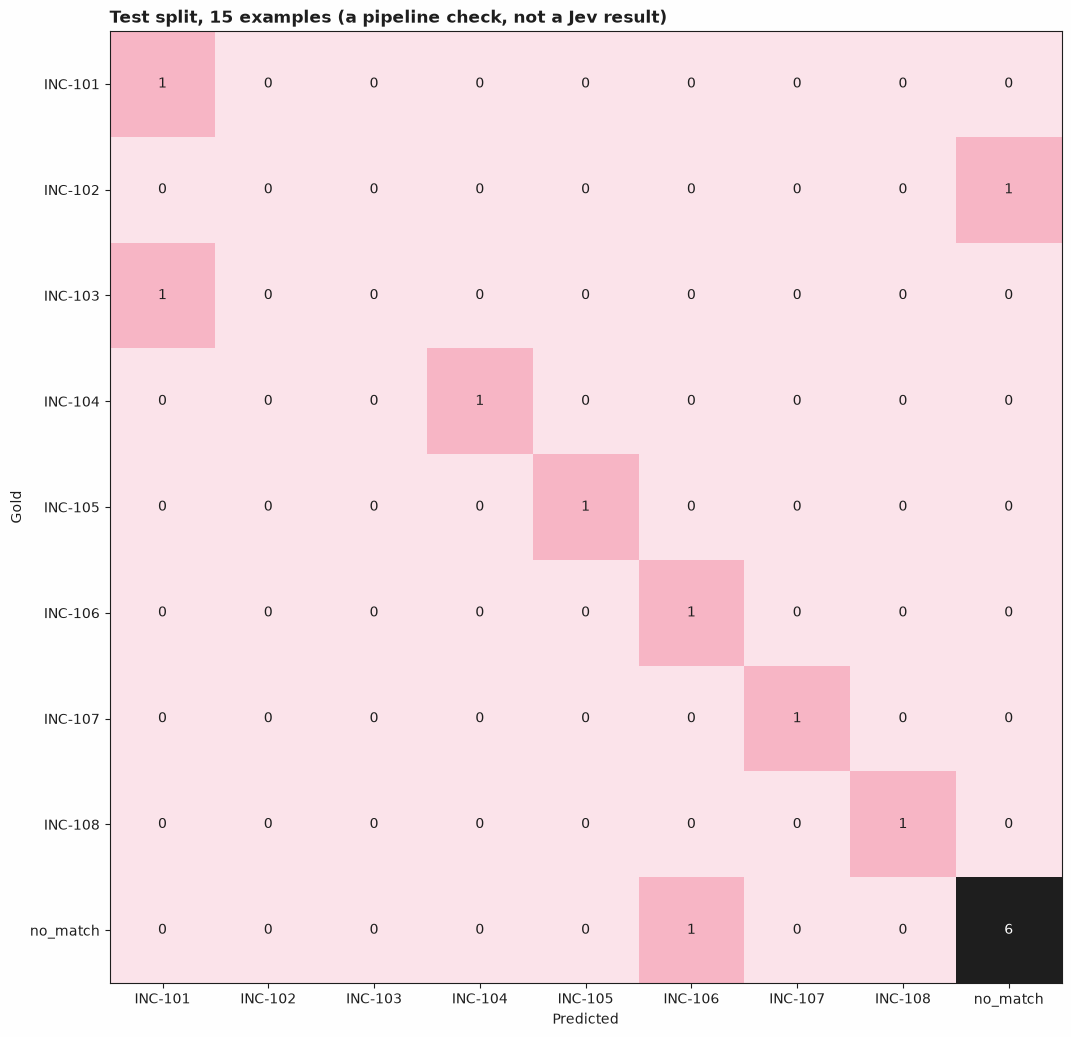

In [10]:
test_examples = select_split(examples, "test")
test_decided = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]
test_answers = [a for _c, a in test_decided]

test_results, test_counts = report(test_examples, test_decided, gate)
print(f"test, {len(test_examples)} examples, confidence gate {gate:.4f} frozen{check}")
print(
    f"match accuracy (top-1 choice vs. gold label): {accuracy(test_gold, test_answers):.4f}{check}"
)
print(
    f"linked: {test_counts[helpers.LINKED]}, review: {test_counts[helpers.REVIEW]}, "
    f"no_duplicate: {test_counts[helpers.NO_DUPLICATE]} (of {len(test_examples)}){check}"
)

all_labels = [*helpers.OPEN_INCIDENTS, helpers.NO_MATCH]
matrix = confusion_matrix(test_gold, test_answers, labels=all_labels)
print("confusion matrix rows = gold, columns = predicted, in this order:")
print(all_labels)
print(matrix.matrix)
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

Three of `test`'s fifteen tickets are wrong, in three different ways, and a fourth is correct but held back for review. `TCK-2007` (`t07-near-cart-wrong`) is gold `no_match` -- the same trap as `TCK-1008` above, a near duplicate of `INC-106` on the wrong service (`wishlist-service`, not `checkout-api`) -- but the stored answer names `INC-106` at a confidence of 0.87, comfortably above the frozen gate: a real, wrong link the confidence gate lets straight through, because the gate only protects against *low* confidence, not against being confidently wrong. `TCK-2011` (`t11-dup-auth-missed`) is a real duplicate of `INC-102`, but the stored answer names `no_match` instead, confidently -- wrong, and not caught by anything, because `match_incident` never runs `no_match` past the confidence gate at all. `TCK-2012` (`t12-dup-search-lowconf`) is a real duplicate of `INC-103`, but the stored answer names a different real candidate at a low confidence: wrong, and caught (sent to `review`). `TCK-2013` (`t13-ambiguous-billing`) is correct but held back by that same low confidence, not wrong. That spread -- one wrong link the gate lets through, one wrong `no_match` the gate was never asked about, and one wrong answer it does catch -- is the point of the outcome summary two cells down.

`TCK-2015` (`t15-dup-email-ranked-second`) is answered correctly and is worth a separate note: it is this recipe's one real incident whose gold match is not the top-ranked candidate (`shortlist` puts `INC-105` first, by word overlap, and the true match, `INC-104`, second), so getting it right needs the same same-service check the wrong-service traps elsewhere in this recipe exercise, not just "pick option 1." Every other real-incident gold label in these fixtures happens to be the shortlist's top candidate; without this one, a rule that always answered the first option would score perfectly on this recipe without ever discriminating among candidates.

In [11]:
per_class = per_class_metrics(test_gold, test_answers, labels=all_labels)
no_match_metrics = per_class[helpers.NO_MATCH]
print(
    f"no_match precision {no_match_metrics.precision:.4f}, recall {no_match_metrics.recall:.4f}, "
    f"support {no_match_metrics.support}{check}"
)

no_match precision 0.8571, recall 0.8571, support 7 (a pipeline check, not a Jev result)


**Support** is how many `test` tickets actually carry the `no_match` gold label (7 here), so a recall figure is only as meaningful as its support is large. `no_match`'s precision (0.8571) is 6 of the 7 tickets the rule called `no_match` that truly had no matching incident: the seventh is `TCK-2011`, a real `INC-102` duplicate the rule misreads as having no match at all. Its recall (0.8571) is 6 of the 7 test tickets truly addressed by no incident: the seventh is `TCK-2007`, which the rule reads as `INC-106` instead -- confidently enough to become the false merge above, but the mistake against `no_match`'s recall is independent of what happens to it afterward. Precision and recall land on the same fraction here only because this fixture set happens to have exactly one error of each kind; nothing ties the two together in general.

## The simulated side effect

`match_incident`'s outcomes are not reapplied through a generic selective-prediction helper here: `no_match` is never gated on confidence at all, so a helper that gates every example on one confidence cut would score a gate this rule does not have. `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)` is the shared helper for exactly this shape of rule: `accepted[i]` is whether `match_incident` answered ticket `i` (`linked` or `no_duplicate`) rather than sending it to `review`, as the rule itself decided, and it reports **coverage** (the fraction of tickets answered), **accuracy** (the fraction of those right) and **risk** (`1 - accuracy`). `helpers.accepted_and_correct` builds its two arguments from a list of `Resolution`s. `evaluate_outcomes` has no notion of a second, narrower outcome inside "answered" -- `linked` versus `no_duplicate` -- so `helpers.false_merge_rate` computes that part directly: the share of `linked` tickets alone whose incident is wrong, the only way the one outcome with a side effect, linking two incidents together, can actually be wrong. `actions` and `queue` below are a `jev_cookbook.simulation.ActionLog` and `ReviewQueue`: nothing here sends, moves or executes anything real (CONTRIBUTING.md, section 4), and every entry says so.

In [12]:
val_gold_by_ticket = {e.fields["ticket_id"]: g for e, g in zip(val_examples, val_gold, strict=True)}
val_accepted, val_correct = helpers.accepted_and_correct(val_results, val_gold_by_ticket)
val_outcomes = evaluate_outcomes(val_accepted, val_correct)
val_fmr = helpers.false_merge_rate(val_results, val_gold_by_ticket)
print(
    f"validation: linked {val_counts[helpers.LINKED]}, reviewed {val_counts[helpers.REVIEW]}, "
    f"no_duplicate {val_counts[helpers.NO_DUPLICATE]} (coverage {val_outcomes.coverage:.4f}){selection}"
)
print(f"accuracy among those answered: {val_outcomes.accuracy:.4f}{selection}")
print(f"risk among those answered: {val_outcomes.risk:.4f}{selection}")
print(f"false-merge rate (wrong among linked): {val_fmr:.4f}{selection}")
print(
    f"simulated actions recorded in validation: {actions_after_validation}, "
    f"items queued for review in validation: {queue_after_validation}{selection}"
)

test_gold_by_ticket = {
    e.fields["ticket_id"]: g for e, g in zip(test_examples, test_gold, strict=True)
}
test_accepted, test_correct = helpers.accepted_and_correct(test_results, test_gold_by_ticket)
test_outcomes = evaluate_outcomes(test_accepted, test_correct)
test_fmr = helpers.false_merge_rate(test_results, test_gold_by_ticket)
print()
print(
    f"test: linked {test_counts[helpers.LINKED]}, reviewed {test_counts[helpers.REVIEW]}, "
    f"no_duplicate {test_counts[helpers.NO_DUPLICATE]} (coverage {test_outcomes.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_outcomes.accuracy:.4f}{check}")
print(f"risk among those answered: {test_outcomes.risk:.4f}{check}")
print(f"false-merge rate (wrong among linked): {test_fmr:.4f}{check}")
print(
    f"simulated actions recorded in test: {len(actions) - actions_after_validation}, "
    f"items queued for review in test: {len(queue) - queue_after_validation}{check}"
)

print()
test_false_merges = [
    r
    for r in test_results
    if r.outcome == helpers.LINKED and r.label != test_gold_by_ticket[r.ticket_id]
]
if test_false_merges:
    merged_ticket = test_false_merges[0].ticket_id
    entry = next(
        e for e in actions.by_kind("link_incident") if e["payload"]["new_incident"] == merged_ticket
    )
    print(f"the one wrong link in test, recorded but never executed{check}:")
    print(json.dumps(entry, indent=2))
else:
    print(f"no false merge occurred in this run{check}")

print()
# Picked explicitly by outcome and ticket id, not by queue position, so the item (when there is
# one) and its label stay matched under the target_accuracy=0.88 exercise below, where
# validation reviews nothing at all -- which is also why this looks up the empty case rather
# than assuming one.
val_review_example = next((r for r in val_results if r.outcome == helpers.REVIEW), None)
if val_review_example is None:
    print(f"no validation ticket was held for review in this run{selection}")
else:
    val_review_entry = next(
        e for e in queue.to_dicts() if e["item"]["new_incident"] == val_review_example.ticket_id
    )
    print(f"one review item from validation, with the candidates it was offered{selection}:")
    print(json.dumps(val_review_entry, indent=2))

validation: linked 6, reviewed 3, no_duplicate 5 (coverage 0.7857) (a selection step, not a reported result)
accuracy among those answered: 1.0000 (a selection step, not a reported result)
risk among those answered: 0.0000 (a selection step, not a reported result)
false-merge rate (wrong among linked): 0.0000 (a selection step, not a reported result)
simulated actions recorded in validation: 6, items queued for review in validation: 3 (a selection step, not a reported result)

test: linked 6, reviewed 2, no_duplicate 7 (coverage 0.8667) (a pipeline check, not a Jev result)
accuracy among those answered: 0.8462 (a pipeline check, not a Jev result)
risk among those answered: 0.1538 (a pipeline check, not a Jev result)
false-merge rate (wrong among linked): 0.1667 (a pipeline check, not a Jev result)
simulated actions recorded in test: 6, items queued for review in test: 2 (a pipeline check, not a Jev result)

the one wrong link in test, recorded but never executed (a pipeline check, not 

`validation`'s risk is 0.0000 and its false-merge rate is 0.0000: the only wrong answer in `validation`, `TCK-1008`, is reviewed rather than answered, so nothing wrong is ever linked or reported there -- that is what choosing the confidence gate on `validation` is supposed to buy, and it does, on this split. `test`'s risk is 0.1538 and its false-merge rate is 0.1667: the two numbers differ because they count different things -- risk counts both `TCK-2007` (the wrong link) and `TCK-2011` (the wrong `no_duplicate`) against the 13 answered tickets, while the false-merge rate counts only `TCK-2007` against the 6 `linked` tickets, since `TCK-2011` never linked anything. A confidence gate chosen to be perfectly accurate on `validation` says nothing about any ticket this recipe has not seen, which is exactly what `test`'s non-zero numbers show. The link recorded above for `TCK-2007` is exactly that false merge: `helpers.record_resolution` wrote it into `actions`, and nothing about running this notebook ever turns that record into a real action on a real incident. The review item above is from `validation` (it is `TCK-1008`, the `v08-near-search-wrong` trap from earlier): it shows the candidates Python actually offered for that ticket, not just the outcome, and it correctly carries the selection label above, not the check label, because it really is a validation item.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 29 scored tickets (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, four of them wrong on purpose and in different ways (one in `validation` itself, a real but wrong candidate named at a low confidence, caught by the gate it goes on to define; one in `test` that is a wrong, confident link the gate lets through; one in `test` that is a wrong, confident `no_match` the gate was never asked about; one in `test` that is wrong but caught by the gate), so every number above describes this fixture set and not a model.

In [13]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard ticket to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `match_incident` sends it.
- Change the confidence gate's target in the evaluation cell (`target_accuracy=1.0` to `0.9`) and check the gate cell above: nothing moves. The loosest cut in the sweep two sections up answers 8 of the 9 real-candidate `validation` answers right (about 0.89 accuracy); any target above that keeps the gate at 0.84, and anything at or below it drops the gate straight to 0.1067 (coverage 1.0, `v08-near-search-wrong` itself now linked). Try `0.89` to see it hold, then `0.88` to see it jump -- the sweep is exactly this cell's search space, so the jump, not a gradual trade-off, is the point.
- Change `SHORTLIST_SIZE` in `helpers.py` from 3 to 2 or 5, rerun the fixture generator and the notebook, and see which tickets get linked differently: a shorter shortlist offers fewer foils (and, near the edge of the pool, can push a real match out of contention entirely); a longer one offers more.
- Neighbouring recipes: [`08-faq-selection`](../08-faq-selection/), which builds on the same shape -- candidates as `Choice` options plus a `no_match` fallback that is never gated on confidence -- for FAQ answers instead of incidents; [`07-word-sense-selection`](../07-word-sense-selection/), which builds a `Choice` option set fresh per example the same way this recipe builds one fresh per ticket, with its own shared `unclear` fallback instead of a side effect.